[2026-05-24 07:54:12 | +0.0s] ================================================================================
[2026-05-24 07:54:12 | +0.0s] 手法ペアごとの日毎変化点数カウント + プロット開始
[2026-05-24 07:54:12 | +0.1s] ================================================================================
[2026-05-24 07:54:12 | +0.2s] 使用CSV: D:\musashino-university\finance\change_point_output_advanced\advanced_change_point_pairs_ALL_ADVANCED_METHODS_20260519_182858.csv
[2026-05-24 07:54:15 | +3.3s] 読み込み行数: 519,754
[2026-05-24 07:54:15 | +3.4s] 列数: 11
[2026-05-24 07:54:15 | +3.4s] ================================================================================
[2026-05-24 07:54:15 | +3.5s] 推定列
[2026-05-24 07:54:15 | +3.5s] series_col   : symbol
[2026-05-24 07:54:15 | +3.5s] datetime_col : cp_datetime
[2026-05-24 07:54:16 | +3.6s] method_col   : method
[2026-05-24 07:54:16 | +3.6s] strength_col : cp_strength
[2026-05-24 07:54:16 | +3.7s] ==============================================================================

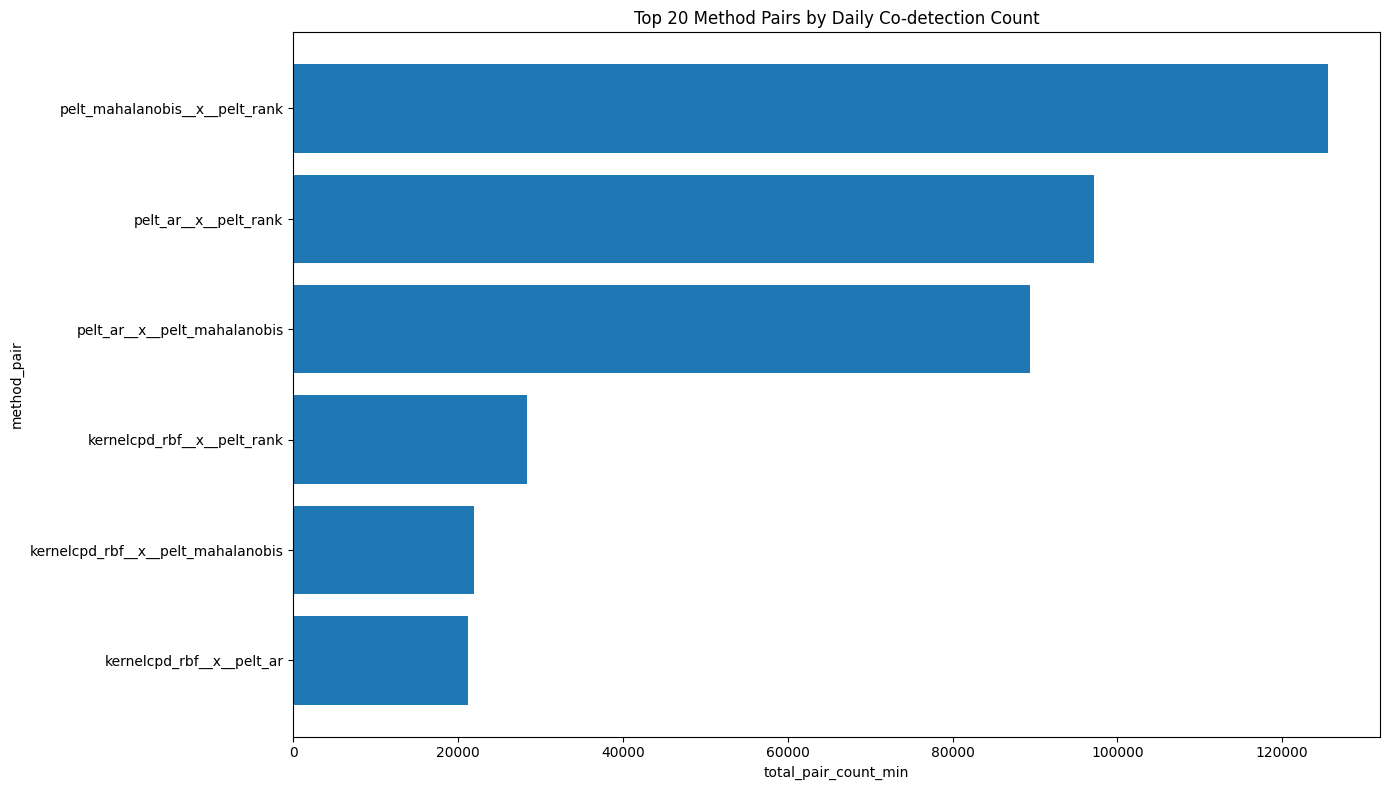

[2026-05-24 07:56:33 | +140.7s] ================================================================================
[2026-05-24 07:56:33 | +140.7s] 手法ペア別の日毎カウント個別プロット開始
[2026-05-24 07:56:35 | +143.1s] 保存: D:\musashino-university\finance\change_point_output_advanced\method_pair_daily_counts\daily_method_pair_pelt_mahalanobis__x__pelt_rank_20260524_075412.png


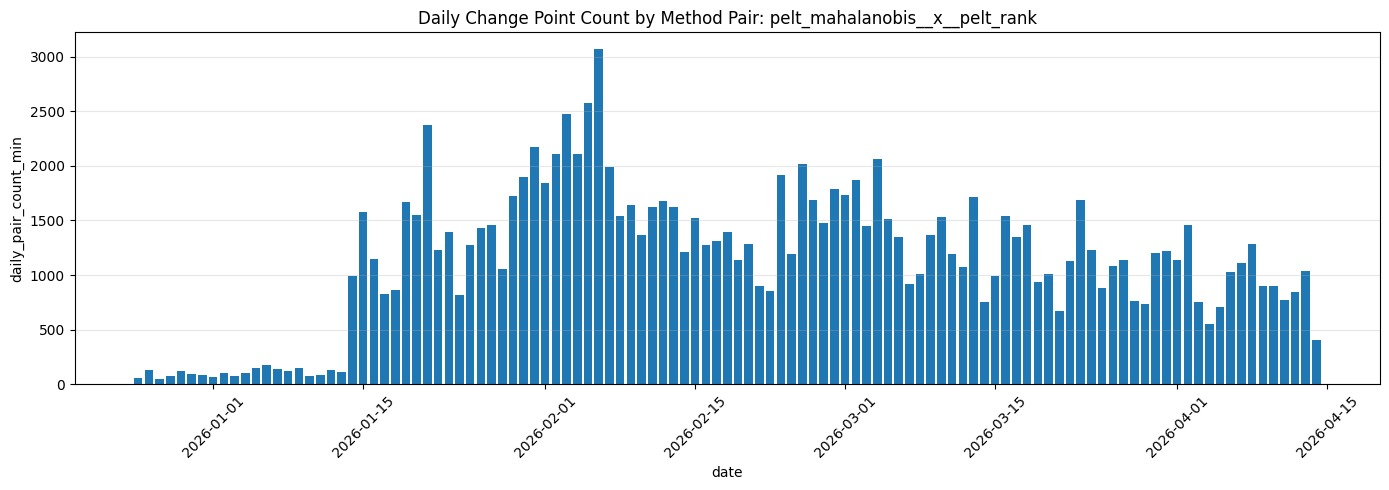

[2026-05-24 07:56:37 | +145.0s] 保存: D:\musashino-university\finance\change_point_output_advanced\method_pair_daily_counts\daily_method_pair_pelt_ar__x__pelt_rank_20260524_075412.png


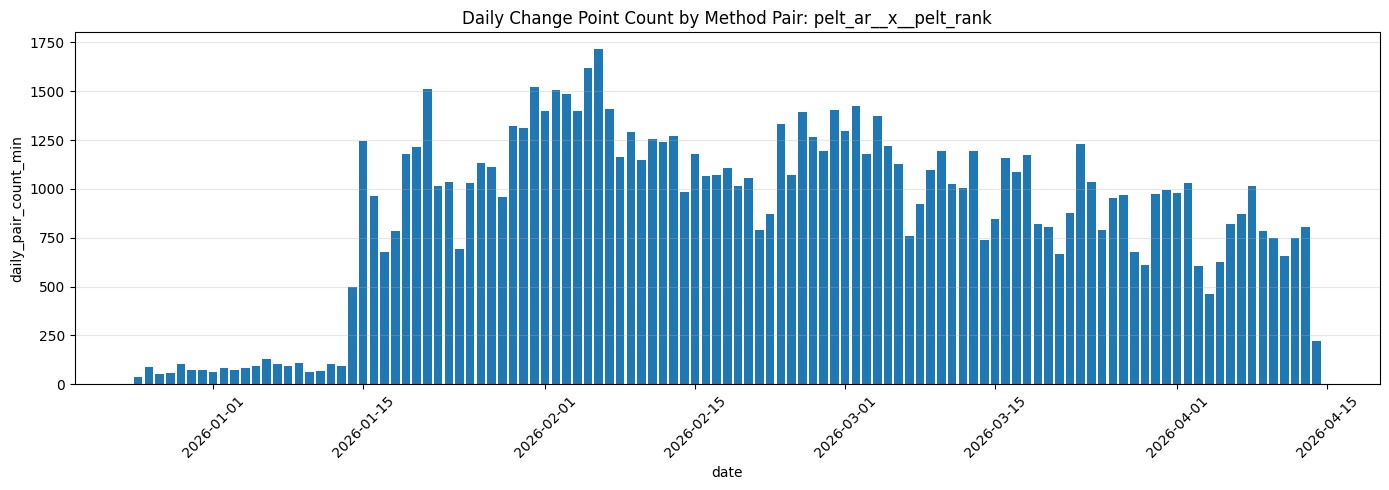

[2026-05-24 07:56:39 | +146.9s] 保存: D:\musashino-university\finance\change_point_output_advanced\method_pair_daily_counts\daily_method_pair_pelt_ar__x__pelt_mahalanobis_20260524_075412.png


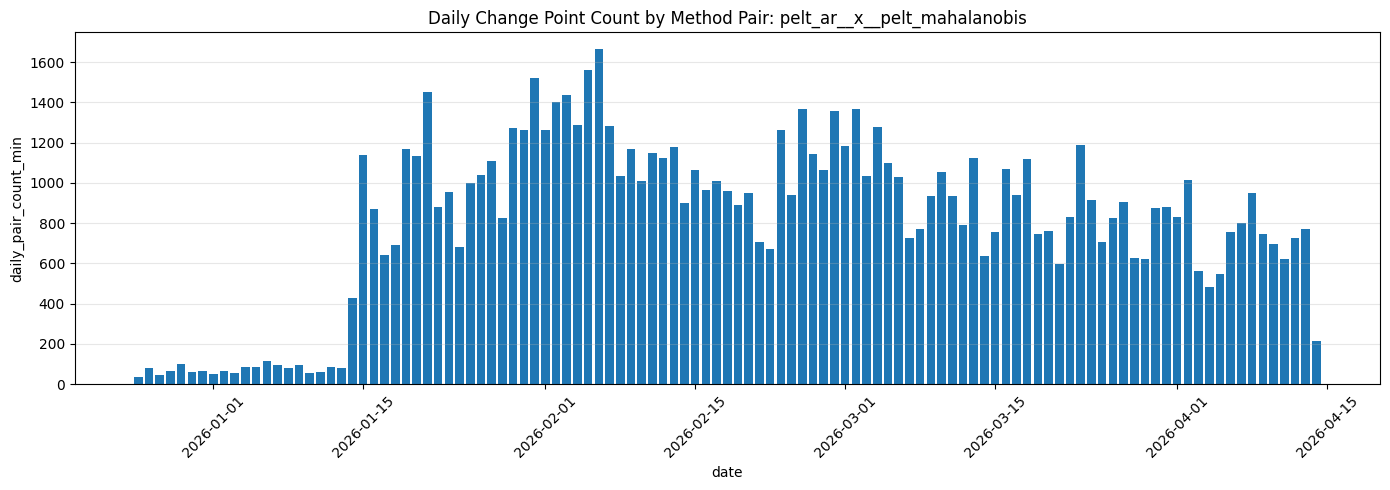

[2026-05-24 07:56:41 | +148.7s] 保存: D:\musashino-university\finance\change_point_output_advanced\method_pair_daily_counts\daily_method_pair_kernelcpd_rbf__x__pelt_rank_20260524_075412.png


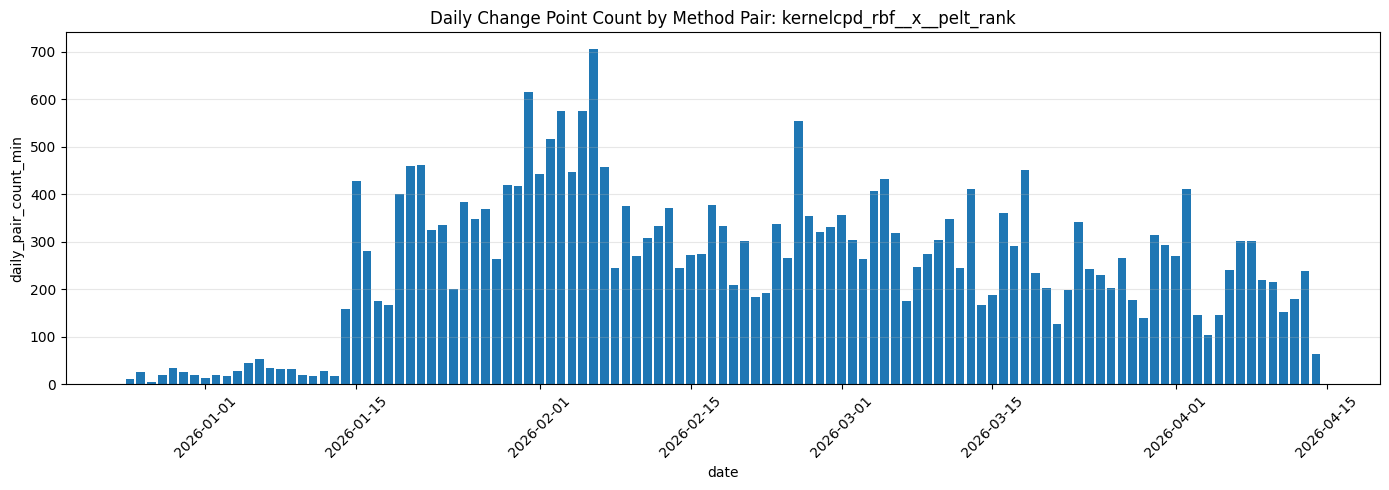

[2026-05-24 07:56:43 | +151.3s] 保存: D:\musashino-university\finance\change_point_output_advanced\method_pair_daily_counts\daily_method_pair_kernelcpd_rbf__x__pelt_mahalanobis_20260524_075412.png


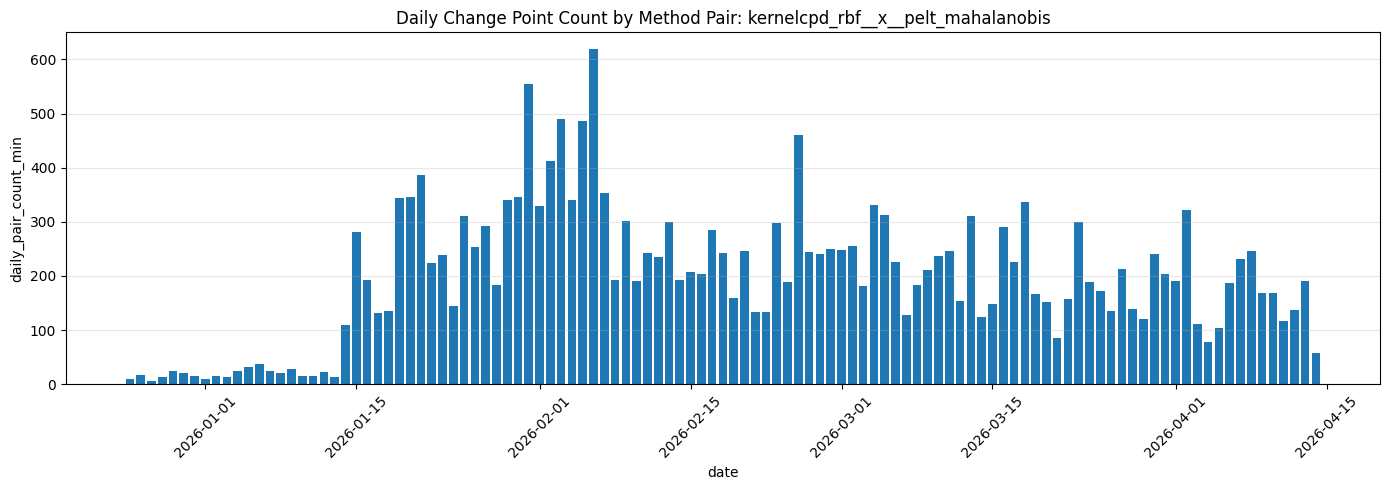

[2026-05-24 07:56:45 | +153.0s] 保存: D:\musashino-university\finance\change_point_output_advanced\method_pair_daily_counts\daily_method_pair_kernelcpd_rbf__x__pelt_ar_20260524_075412.png


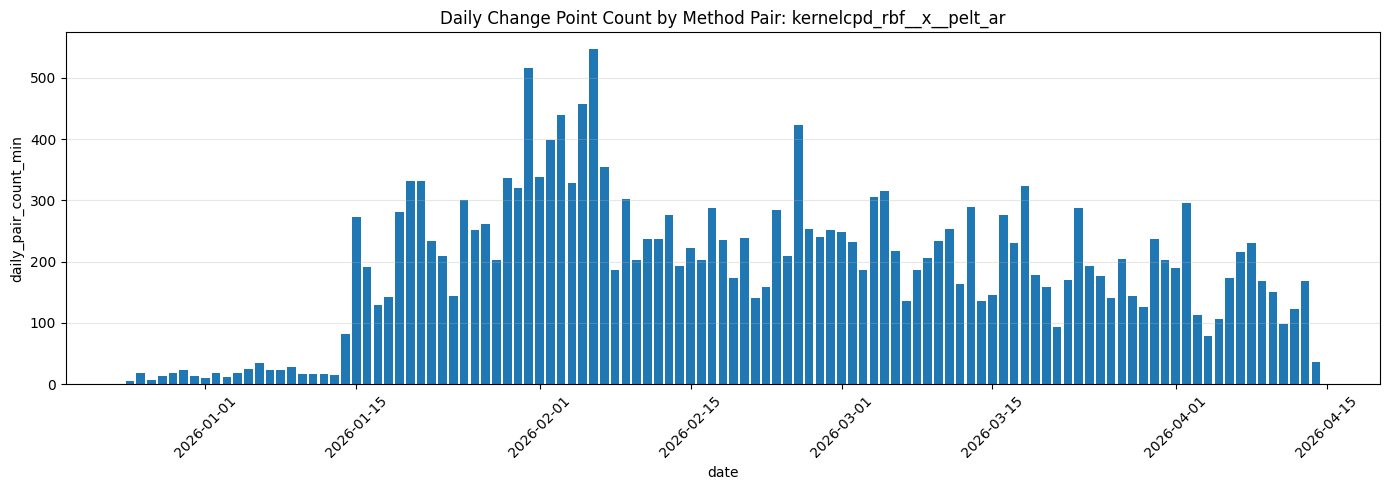

[2026-05-24 07:56:46 | +153.6s] ================================================================================
[2026-05-24 07:56:46 | +153.6s] 手法ペア別の日毎カウント2列subplot開始
[2026-05-24 07:56:53 | +160.7s] 2列subplot保存: D:\musashino-university\finance\change_point_output_advanced\method_pair_daily_counts\daily_method_pair_counts_2col_subplot_top20_20260524_075412.png


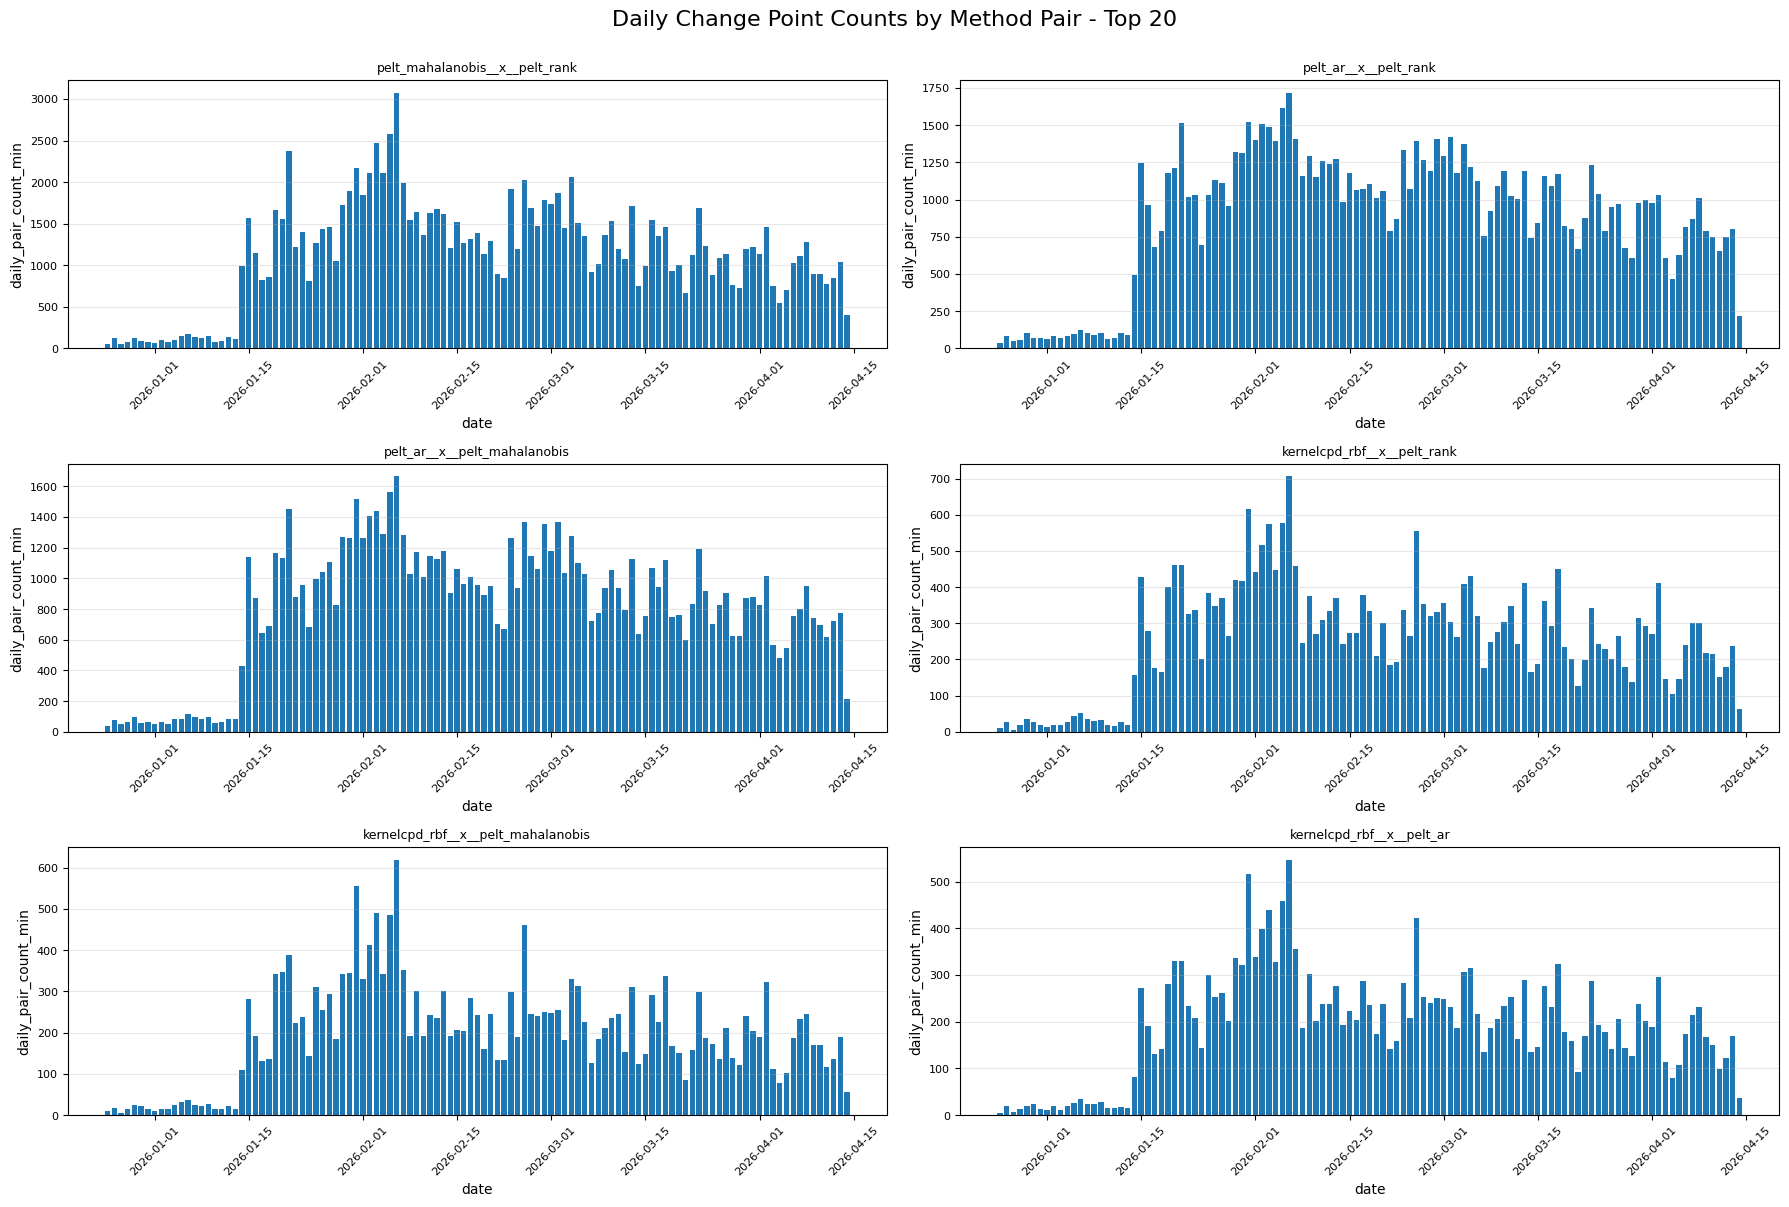

[2026-05-24 07:56:55 | +163.4s] ================================================================================
[2026-05-24 07:56:55 | +163.5s] 完了
[2026-05-24 07:56:55 | +163.5s] 出力ディレクトリ: D:\musashino-university\finance\change_point_output_advanced\method_pair_daily_counts
[2026-05-24 07:56:55 | +163.6s] ログ: D:\musashino-university\finance\change_point_output_advanced\method_pair_daily_counts\method_pair_daily_counts_log_20260524_075412.txt
[2026-05-24 07:56:56 | +163.6s] ================================================================================


In [1]:
# =============================================================================
# 手法ペアごとの日毎変化点数カウント + プロット 完全版
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from itertools import combinations
import time
import re

# =============================================================================
# パラメータ
# =============================================================================

CHANGE_POINT_DIR = Path(r"D:\musashino-university\finance\change_point_output_advanced")

PAIRS_PATTERN = "advanced_change_point_pairs_ALL_ADVANCED_METHODS_*.csv"

OUTPUT_DIR = CHANGE_POINT_DIR / "method_pair_daily_counts"
OUTPUT_DIR.mkdir(exist_ok=True)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

ENCODING_OUT = "utf-8-sig"

SHOW_PLOTS = True
SAVE_PLOTS = True
PLOT_DPI = 200

# 表示する手法ペア数
TOP_METHOD_PAIRS = 20

# まとめsubplotの列数
SUBPLOT_COLS = 2

# =============================================================================
# ログ
# =============================================================================

START_TIME = time.time()
LOG_FILE = OUTPUT_DIR / f"method_pair_daily_counts_log_{RUN_ID}.txt"

def log(msg=""):
    elapsed = time.time() - START_TIME
    line = f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')} | +{elapsed:.1f}s] {msg}"
    print(line)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(line + "\n")


# =============================================================================
# 補助関数
# =============================================================================

def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def safe_name(s):
    s = str(s)
    s = re.sub(r'[\\/:*?"<>|]', "_", s)
    s = s.replace(" ", "_")
    return s[:140]


def load_latest_file(directory, pattern):
    files = sorted(directory.glob(pattern))
    if not files:
        raise FileNotFoundError(f"対象ファイルが見つかりません: {directory / pattern}")
    return max(files, key=lambda p: p.stat().st_mtime)


def infer_pairs_columns(df):
    series_col = find_column(
        df,
        [
            "coin",
            "symbol",
            "ticker",
            "file",
            "filename",
            "series",
            "name",
        ],
    )

    datetime_col = find_column(
        df,
        [
            "cp_datetime",
            "datetime",
            "timestamp",
            "date",
            "time",
            "Date",
            "Datetime",
            "Timestamp",
        ],
    )

    method_col = find_column(
        df,
        [
            "method",
            "algo",
            "algorithm",
            "model",
        ],
    )

    strength_col = find_column(
        df,
        [
            "cp_strength",
            "strength",
            "score",
            "change_strength",
            "cp_score",
        ],
    )

    return series_col, datetime_col, method_col, strength_col


# =============================================================================
# 手法ペア集計関数
# =============================================================================

def count_daily_change_points_by_method_pair(
    pairs_df,
    series_col,
    datetime_col,
    method_col,
):
    log("=" * 80)
    log("手法ペアごとの日毎変化点数カウント開始")

    if method_col is None:
        raise ValueError("method列が見つからないため、手法ペア集計できません。")

    df = pairs_df.copy()

    df[datetime_col] = pd.to_datetime(df[datetime_col], errors="coerce")
    df = df.dropna(subset=[datetime_col, method_col])

    df["cp_date"] = df[datetime_col].dt.date
    df[method_col] = df[method_col].astype(str)

    rows = []

    grouped = df.groupby([series_col, "cp_date"])

    for (series_name, cp_date), g in grouped:

        methods = sorted(g[method_col].dropna().unique())

        if len(methods) < 2:
            continue

        for m1, m2 in combinations(methods, 2):

            count_m1 = int((g[method_col] == m1).sum())
            count_m2 = int((g[method_col] == m2).sum())

            pair_count_min = min(count_m1, count_m2)
            pair_count_sum = count_m1 + count_m2

            rows.append(
                {
                    "series_name": series_name,
                    "cp_date": cp_date,
                    "method_1": m1,
                    "method_2": m2,
                    "method_pair": f"{m1}__x__{m2}",
                    "count_method_1": count_m1,
                    "count_method_2": count_m2,
                    "daily_method_pair_count_min": pair_count_min,
                    "daily_method_pair_count_sum": pair_count_sum,
                }
            )

    result_df = pd.DataFrame(rows)

    detail_csv = OUTPUT_DIR / f"daily_method_pair_counts_DETAIL_{RUN_ID}.csv"

    result_df.to_csv(
        detail_csv,
        index=False,
        encoding=ENCODING_OUT,
    )

    log(f"詳細CSV保存: {detail_csv}")

    if len(result_df) == 0:
        log("手法ペアの日毎カウントは空でした。")
        return result_df, pd.DataFrame(), pd.DataFrame()

    # -------------------------------------------------------------------------
    # 全銘柄合計：日付ごと・手法ペアごと
    # -------------------------------------------------------------------------

    daily_sum_df = (
        result_df
        .groupby(["method_pair", "cp_date"], as_index=False)
        .agg(
            daily_pair_count_min=("daily_method_pair_count_min", "sum"),
            daily_pair_count_sum=("daily_method_pair_count_sum", "sum"),
            active_series_count=("series_name", "nunique"),
        )
    )

    daily_sum_csv = OUTPUT_DIR / f"daily_method_pair_counts_SUM_{RUN_ID}.csv"

    daily_sum_df.to_csv(
        daily_sum_csv,
        index=False,
        encoding=ENCODING_OUT,
    )

    log(f"日別合計CSV保存: {daily_sum_csv}")

    # -------------------------------------------------------------------------
    # 手法ペア総合ランキング
    # -------------------------------------------------------------------------

    ranking_df = (
        result_df
        .groupby("method_pair", as_index=False)
        .agg(
            total_pair_count_min=("daily_method_pair_count_min", "sum"),
            total_pair_count_sum=("daily_method_pair_count_sum", "sum"),
            active_days=("cp_date", "nunique"),
            active_series=("series_name", "nunique"),
        )
        .sort_values(
            ["total_pair_count_min", "active_days"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

    ranking_df.insert(0, "rank", np.arange(1, len(ranking_df) + 1))

    ranking_csv = OUTPUT_DIR / f"method_pair_ranking_{RUN_ID}.csv"

    ranking_df.to_csv(
        ranking_csv,
        index=False,
        encoding=ENCODING_OUT,
    )

    log(f"ランキングCSV保存: {ranking_csv}")

    return result_df, daily_sum_df, ranking_df


# =============================================================================
# プロット関数
# =============================================================================

def plot_method_pair_ranking(ranking_df):
    if len(ranking_df) == 0:
        return

    log("=" * 80)
    log("手法ペアランキングプロット開始")

    plot_df = ranking_df.head(TOP_METHOD_PAIRS).copy()
    plot_df = plot_df.sort_values("total_pair_count_min", ascending=True)

    plt.figure(figsize=(14, 8))

    plt.barh(
        plot_df["method_pair"],
        plot_df["total_pair_count_min"],
    )

    plt.xlabel("total_pair_count_min")
    plt.ylabel("method_pair")
    plt.title(f"Top {TOP_METHOD_PAIRS} Method Pairs by Daily Co-detection Count")
    plt.tight_layout()

    out_png = OUTPUT_DIR / f"top{TOP_METHOD_PAIRS}_method_pair_ranking_{RUN_ID}.png"

    if SAVE_PLOTS:
        plt.savefig(out_png, dpi=PLOT_DPI, bbox_inches="tight")
        log(f"保存: {out_png}")

    if SHOW_PLOTS:
        plt.show()

    plt.close()


def plot_daily_counts_for_each_method_pair(daily_sum_df, ranking_df):
    if len(daily_sum_df) == 0:
        return

    log("=" * 80)
    log("手法ペア別の日毎カウント個別プロット開始")

    top_pairs = ranking_df.head(TOP_METHOD_PAIRS)["method_pair"].tolist()

    for method_pair in top_pairs:

        g = daily_sum_df[daily_sum_df["method_pair"] == method_pair].copy()
        g = g.sort_values("cp_date")

        plt.figure(figsize=(14, 5))

        plt.bar(
            g["cp_date"],
            g["daily_pair_count_min"],
        )

        plt.title(f"Daily Change Point Count by Method Pair: {method_pair}")
        plt.xlabel("date")
        plt.ylabel("daily_pair_count_min")
        plt.xticks(rotation=45)
        plt.grid(True, axis="y", alpha=0.3)
        plt.tight_layout()

        out_png = OUTPUT_DIR / f"daily_method_pair_{safe_name(method_pair)}_{RUN_ID}.png"

        if SAVE_PLOTS:
            plt.savefig(out_png, dpi=PLOT_DPI, bbox_inches="tight")
            log(f"保存: {out_png}")

        if SHOW_PLOTS:
            plt.show()

        plt.close()


def plot_daily_counts_subplot(daily_sum_df, ranking_df):
    if len(daily_sum_df) == 0:
        return

    log("=" * 80)
    log("手法ペア別の日毎カウント2列subplot開始")

    top_pairs = ranking_df.head(TOP_METHOD_PAIRS)["method_pair"].tolist()

    n = len(top_pairs)
    ncols = SUBPLOT_COLS
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(18, 4 * nrows),
        squeeze=False,
    )

    axes = axes.reshape(-1)

    for i, method_pair in enumerate(top_pairs):

        ax = axes[i]

        g = daily_sum_df[daily_sum_df["method_pair"] == method_pair].copy()
        g = g.sort_values("cp_date")

        ax.bar(
            g["cp_date"],
            g["daily_pair_count_min"],
        )

        ax.set_title(method_pair, fontsize=9)
        ax.set_xlabel("date")
        ax.set_ylabel("daily_pair_count_min")
        ax.grid(True, axis="y", alpha=0.3)
        ax.tick_params(axis="x", labelrotation=45, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"Daily Change Point Counts by Method Pair - Top {TOP_METHOD_PAIRS}",
        fontsize=16,
        y=1.002,
    )

    plt.tight_layout()

    out_png = OUTPUT_DIR / f"daily_method_pair_counts_2col_subplot_top{TOP_METHOD_PAIRS}_{RUN_ID}.png"

    if SAVE_PLOTS:
        plt.savefig(out_png, dpi=PLOT_DPI, bbox_inches="tight")
        log(f"2列subplot保存: {out_png}")

    if SHOW_PLOTS:
        plt.show()

    plt.close()


# =============================================================================
# メイン処理
# =============================================================================

log("=" * 80)
log("手法ペアごとの日毎変化点数カウント + プロット開始")
log("=" * 80)

pairs_csv = load_latest_file(CHANGE_POINT_DIR, PAIRS_PATTERN)

log(f"使用CSV: {pairs_csv}")

pairs_df = pd.read_csv(pairs_csv)

log(f"読み込み行数: {len(pairs_df):,}")
log(f"列数: {len(pairs_df.columns)}")

series_col, datetime_col, method_col, strength_col = infer_pairs_columns(pairs_df)

log("=" * 80)
log("推定列")
log(f"series_col   : {series_col}")
log(f"datetime_col : {datetime_col}")
log(f"method_col   : {method_col}")
log(f"strength_col : {strength_col}")

if series_col is None:
    raise ValueError("銘柄列が見つかりません。")

if datetime_col is None:
    raise ValueError("日時列が見つかりません。")

if method_col is None:
    raise ValueError("method列が見つかりません。")

detail_df, daily_sum_df, ranking_df = count_daily_change_points_by_method_pair(
    pairs_df=pairs_df,
    series_col=series_col,
    datetime_col=datetime_col,
    method_col=method_col,
)

log("=" * 80)
log("手法ペアランキング TOP")
if len(ranking_df) > 0:
    print(ranking_df.head(TOP_METHOD_PAIRS).to_string(index=False))

plot_method_pair_ranking(ranking_df)

plot_daily_counts_for_each_method_pair(
    daily_sum_df=daily_sum_df,
    ranking_df=ranking_df,
)

plot_daily_counts_subplot(
    daily_sum_df=daily_sum_df,
    ranking_df=ranking_df,
)

log("=" * 80)
log("完了")
log(f"出力ディレクトリ: {OUTPUT_DIR}")
log(f"ログ: {LOG_FILE}")
log("=" * 80)